In [1]:
# Import necessary libraries
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
from circuit_utils import create_test_circuit
from experiment import circuit_knitter, ExperimentConfig

In [2]:
def sort_quantum_states(states_dict):
    """Sort quantum states numerically from |000...> to |111...>"""    
    # Sort by the integer value of the binary string (remove spaces first)
    return dict(sorted(states_dict.items(), key=lambda x: int(x[0].replace(' ', ''), 2) if x[0] else 0))

### Quantum Circuit Evaluation

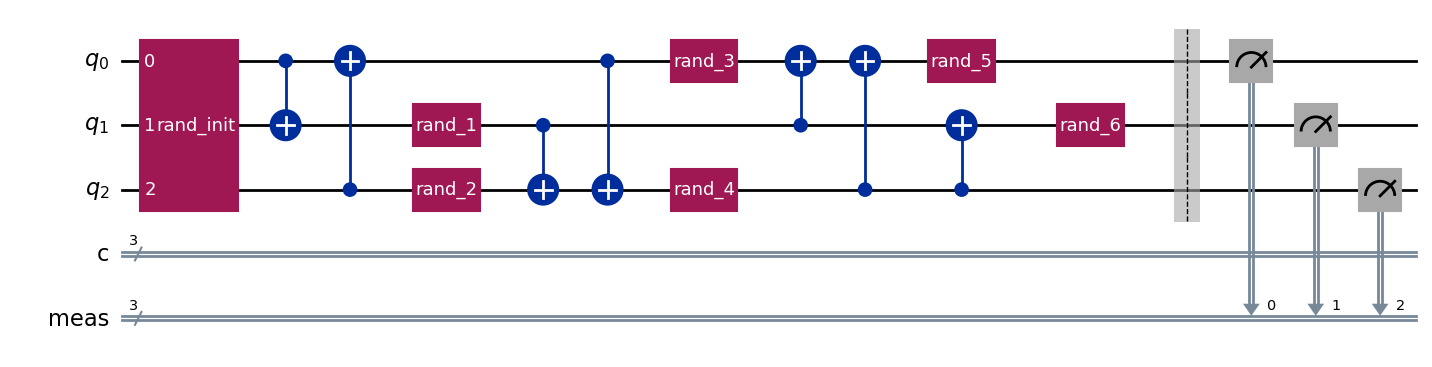

In [3]:
# Create the test circuit using the function from circuit_utils
qc = create_test_circuit()

# Add measurements to the circuit
qc.measure_all()

# Display the circuit diagram
qc.draw('mpl')

Measurement results (ratios):
|010 000>: 0.1565
|001 000>: 0.0256
|110 000>: 0.0720
|000 000>: 0.0847
|101 000>: 0.0392
|011 000>: 0.3394
|100 000>: 0.0777
|111 000>: 0.2049


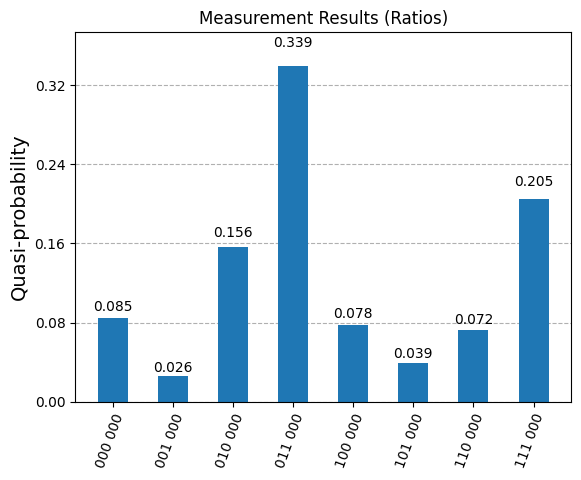

In [4]:
# Set the number of shots for simulation
simulation_shots = 1024**2

# Simulate the circuit with the specified number of shots
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=simulation_shots)
result = job.result()
counts = result.get_counts()

# Convert counts to ratios
total_shots = sum(counts.values())
ratios = {key: value / total_shots for key, value in counts.items()}

# Display the results
print('Measurement results (ratios):')
for state, ratio in ratios.items():
    print(f'|{state}>: {ratio:.4f}')

# Plot the histogram of results
plot_histogram(ratios, title='Measurement Results (Ratios)')

Circuit knitting results for qubits 0 and 2:
|000>: 74.125
|001>: 20.25
|010>: 163.625
|011>: 392.25
|100>: 65.875
|101>: 27.25
|110>: 78.375
|111>: 209.0


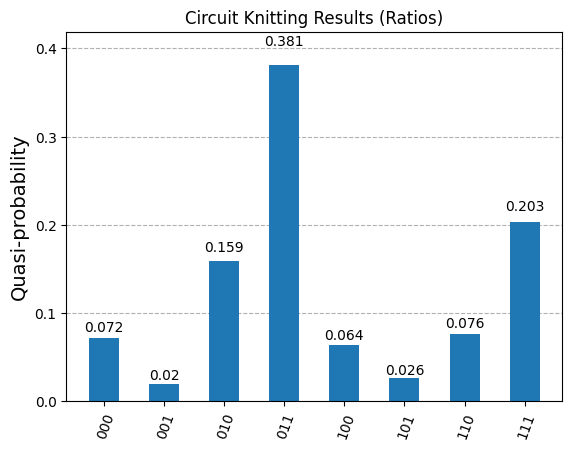

In [5]:
# Set the number of shots for circuit knitting
knitting_shots = 1024

# Set the qubit range for circuit knitting
start_qubit = 0
end_qubit = 2

# Apply circuit knitter to the specified qubit range
config = ExperimentConfig(noise=False, optimization_level=1, num_shots=knitting_shots, results_dir='results')
knitting_result = circuit_knitter(qc, start_qubit=start_qubit, end_qubit=end_qubit, num_shots=knitting_shots, config=config)

# Display knitting results
print(f'Circuit knitting results for qubits {start_qubit} and {end_qubit}:')
results = knitting_result['results']
for state, count in results.items():
    print(f'|{state}>: {count}')

# Convert counts to ratios for histogram
total_shots = sum(knitting_result['results'].values())
ratios = {key: value / total_shots for key, value in knitting_result['results'].items()}

# Plot the histogram of knitting results
plot_histogram(ratios, title='Circuit Knitting Results (Ratios)')

Running evaluation 1/16...
Running evaluation 2/16...
Running evaluation 3/16...
Running evaluation 4/16...
Running evaluation 5/16...
Running evaluation 6/16...
Running evaluation 7/16...
Running evaluation 8/16...
Running evaluation 9/16...
Running evaluation 10/16...
Running evaluation 11/16...
Running evaluation 12/16...
Running evaluation 13/16...
Running evaluation 14/16...
Running evaluation 15/16...
Running evaluation 16/16...

Overall average measurement results (ratios):
|000>: 0.0852 ± 0.000021
|001>: 0.0253 ± 0.000009
|010>: 0.1559 ± 0.000019
|011>: 0.3397 ± 0.000028
|100>: 0.0774 ± 0.000016
|101>: 0.0391 ± 0.000011
|110>: 0.0728 ± 0.000021
|111>: 0.2045 ± 0.000021


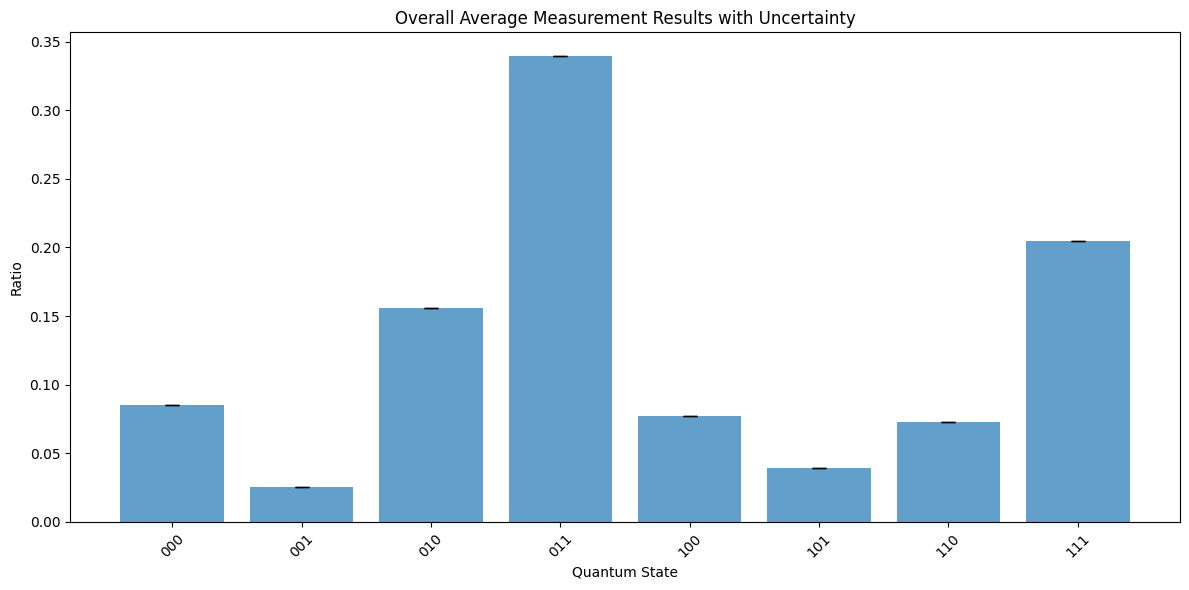

In [6]:
# Evaluate the test circuit 16 times with (1024**2)/16 shots each
num_evaluations = 16
shots_per_evaluation = (1024**2) // 16

# Store results from each evaluation
all_results = []

# Run multiple evaluations
for i in range(num_evaluations):
    print(f'Running evaluation {i+1}/{num_evaluations}...')
    job = simulator.run(compiled_circuit, shots=shots_per_evaluation)
    result = job.result()
    counts = result.get_counts()
    all_results.append(counts)

# Combine all results
combined_counts = {}
for counts in all_results:
    for state, count in counts.items():
        if state in combined_counts:
            combined_counts[state] += count
        else:
            combined_counts[state] = count

# Calculate overall average and uncertainty
total_shots_combined = sum(combined_counts.values())
ratios = {key: value / total_shots_combined for key, value in combined_counts.items()}

# Calculate uncertainty (standard error of the mean)
uncertainties = {}
for state in combined_counts.keys():
    state_counts = [counts.get(state, 0) for counts in all_results]
    std_dev = np.std(state_counts, ddof=1)
    uncertainty = std_dev / np.sqrt(num_evaluations)
    uncertainties[state] = uncertainty / total_shots_combined

# Sort quantum states numerically
ratios = sort_quantum_states(ratios)
uncertainties = sort_quantum_states(uncertainties)

# Remove trailing ' 000' from state labels for display
cleaned_states = {state.replace(' 000', ''): value for state, value in ratios.items()}
cleaned_uncertainties = {state.replace(' 000', ''): value for state, value in uncertainties.items()}

# Display results
print('\nOverall average measurement results (ratios):')
for state, ratio in cleaned_states.items():
    unc = cleaned_uncertainties.get(state, 0)
    print(f'|{state}>: {ratio:.4f} ± {unc:.6f}')

# Plot the overall average with uncertainty
states = list(cleaned_states.keys())
values = list(cleaned_states.values())
errors = list(cleaned_uncertainties.values())

plt.figure(figsize=(12, 6))
plt.bar(states, values, yerr=errors, capsize=5, alpha=0.7)
plt.title('Overall Average Measurement Results with Uncertainty')
plt.xlabel('Quantum State')
plt.ylabel('Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Running knitting evaluation 1/4...
Running knitting evaluation 2/4...
Running knitting evaluation 3/4...
Running knitting evaluation 4/4...

Overall average knitting results (ratios):
|000>: 0.0963 ± 0.006928
|001>: 0.0987 ± 0.010213
|010>: 0.1440 ± 0.010707
|011>: 0.2672 ± 0.009493
|100>: 0.0264 ± 0.008592
|101>: 0.0963 ± 0.010178
|110>: 0.0420 ± 0.009473
|111>: 0.2290 ± 0.009297


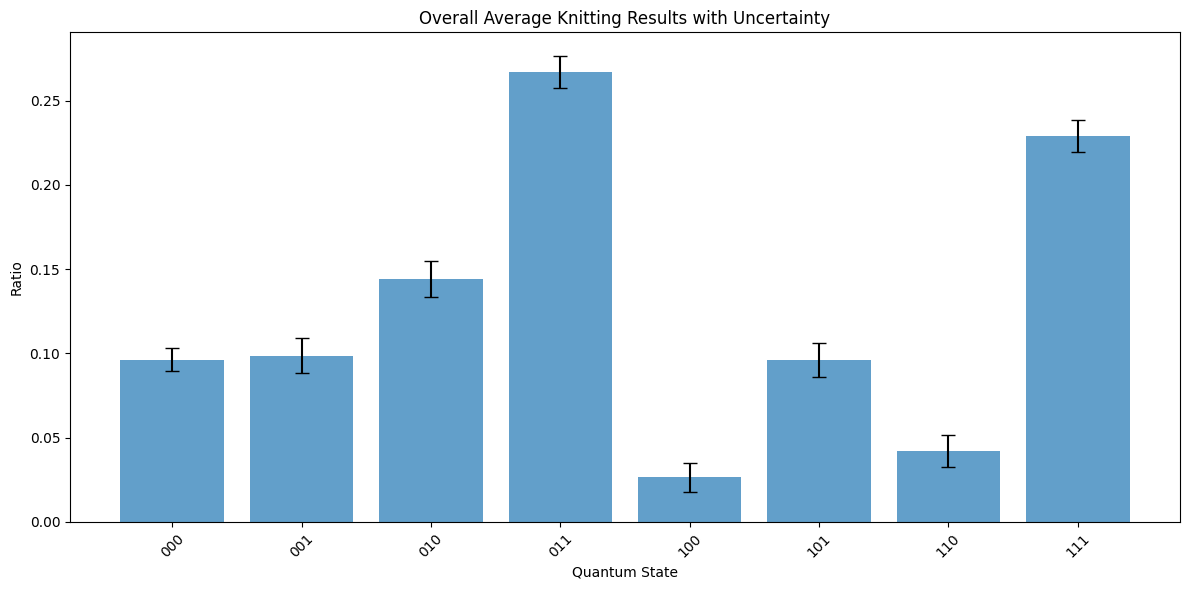

In [7]:
# Evaluate the knitted circuit 16 times with 1024 shots per evaluation
num_knitting_evaluations = 4
shots_per_knitting_evaluation = 256 // 4

# Store results from each knitting evaluation
all_knitting_results = []

# Run multiple knitting evaluations
for i in range(num_knitting_evaluations):
    print(f'Running knitting evaluation {i+1}/{num_knitting_evaluations}...')
    knitting_result = circuit_knitter(qc, start_qubit=start_qubit, end_qubit=end_qubit, 
                                      num_shots=shots_per_knitting_evaluation, config=config)
    all_knitting_results.append(knitting_result['results'])

# Combine all knitting results
combined_knitting_counts = {}
for counts in all_knitting_results:
    for state, count in counts.items():
        if state in combined_knitting_counts:
            combined_knitting_counts[state] += count
        else:
            combined_knitting_counts[state] = count

# Calculate overall average and uncertainty for knitting results
total_knitting_shots = sum(combined_knitting_counts.values())
knitting_ratios = {key: value / total_knitting_shots for key, value in combined_knitting_counts.items()}

# Calculate uncertainty (standard error of the mean)
knitting_uncertainties = {}
for state in combined_knitting_counts.keys():
    state_counts = [counts.get(state, 0) for counts in all_knitting_results]
    std_dev = np.std(state_counts, ddof=1)
    uncertainty = std_dev / np.sqrt(num_knitting_evaluations)
    knitting_uncertainties[state] = uncertainty / total_knitting_shots

# Display knitting results
print('\nOverall average knitting results (ratios):')
for state, ratio in knitting_ratios.items():
    unc = knitting_uncertainties.get(state, 0)
    print(f'|{state}>: {ratio:.4f} ± {unc:.6f}')

# Plot the overall average with uncertainty for knitting results
states = list(knitting_ratios.keys())
values = list(knitting_ratios.values())
errors = list(knitting_uncertainties.values())

plt.figure(figsize=(12, 6))
plt.bar(states, values, yerr=errors, capsize=5, alpha=0.7)
plt.title('Overall Average Knitting Results with Uncertainty')
plt.xlabel('Quantum State')
plt.ylabel('Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()